<a href="https://colab.research.google.com/github/ManuelRomero2025/CienciasdeDatos1/blob/main/PCA_01_20252.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#https://python-graph-gallery.com/47-faceted-scatter-plot-with-seaborn/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
# Asegúrate de haber montado Google Drive previamente
from google.colab import drive
drive.mount('/content/drive')

# Leer el archivo desde Drive

df = pd.read_csv('/content/drive/MyDrive/CienciasDatos2025/World-happiness-report-2024.csv')

Mounted at /content/drive


In [3]:
df.head()

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [4]:
df.describe()

,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
count,143.000000,143.000000,143.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.527580,5.641175,5.413972,1.378807,1.134329,0.520886,0.620621,0.146271,0.154121,1.575914
std,1.170717,1.155008,1.187133,0.425098,0.333317,0.164923,0.162492,0.073441,0.126238,0.537459
min,1.721000,1.775000,1.667000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.726000,4.845500,4.606000,1.077750,0.921750,0.398000,0.527500,0.091000,0.068750,1.308250
50%,5.785000,5.895000,5.674000,1.431500,1.237500,0.549500,0.641000,0.136500,0.120500,1.644500
75%,6.416000,6.507500,6.319000,1.741500,1.383250,0.648500,0.736000,0.192500,0.193750,1.881750
max,7.741000,7.815000,7.667000,2.141000,1.617000,0.857000,0.863000,0.401000,0.575000,2.998000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB


In [6]:
df.isnull().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
upperwhisker,0
lowerwhisker,0
Log GDP per capita,3
Social support,3
Healthy life expectancy,3
Freedom to make life choices,3
Generosity,3


In [7]:
# Perfecto, vamos a aplicar lo que indicas:
# Llenar los valores faltantes de columnas numéricas con la media de cada columna

# Seleccionar columnas numéricas
numeric_cols = df.select_dtypes(include=np.number).columns

# Rellenar los valores faltantes con la media de cada columna numérica
df_1 = df.copy() # Aquí también se reemplaza 'df_original' con 'df'
df_1[numeric_cols] = df_1[numeric_cols].fillna(df_1[numeric_cols].mean())

# Verificar si quedaron valores faltantes
missing_after = df_1.isnull().sum().sum()

missing_after

np.int64(0)

In [8]:
df_1.describe()


,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
count,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000
mean,5.527580,5.641175,5.413972,1.378807,1.134329,0.520886,0.620621,0.146271,0.154121,1.575914
std,1.170717,1.155008,1.187133,0.420584,0.329777,0.163171,0.160766,0.072661,0.124898,0.531751
min,1.721000,1.775000,1.667000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.726000,4.845500,4.606000,1.079000,0.924500,0.400000,0.531000,0.092500,0.069000,1.317000
50%,5.785000,5.895000,5.674000,1.403000,1.217000,0.549000,0.632000,0.138000,0.122000,1.640000
75%,6.416000,6.507500,6.319000,1.733000,1.377000,0.644000,0.734000,0.191500,0.191000,1.879500
max,7.741000,7.815000,7.667000,2.141000,1.617000,0.857000,0.863000,0.401000,0.575000,2.998000


In [9]:
df_1.isnull().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
upperwhisker,0
lowerwhisker,0
Log GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0


In [10]:
df_1['Country name'].unique()

array(['Finland', 'Denmark', 'Iceland', 'Sweden', 'Israel', 'Netherlands',
       'Norway', 'Luxembourg', 'Switzerland', 'Australia', 'New Zealand',
       'Costa Rica', 'Kuwait', 'Austria', 'Canada', 'Belgium', 'Ireland',
       'Czechia', 'Lithuania', 'United Kingdom', 'Slovenia',
       'United Arab Emirates', 'United States', 'Germany', 'Mexico',
       'Uruguay', 'France', 'Saudi Arabia', 'Kosovo', 'Singapore',
       'Taiwan Province of China', 'Romania', 'El Salvador', 'Estonia',
       'Poland', 'Spain', 'Serbia', 'Chile', 'Panama', 'Malta', 'Italy',
       'Guatemala', 'Nicaragua', 'Brazil', 'Slovakia', 'Latvia',
       'Uzbekistan', 'Argentina', 'Kazakhstan', 'Cyprus', 'Japan',
       'South Korea', 'Philippines', 'Vietnam', 'Portugal', 'Hungary',
       'Paraguay', 'Thailand', 'Malaysia', 'China', 'Honduras', 'Bahrain',
       'Croatia', 'Greece', 'Bosnia and Herzegovina', 'Libya', 'Jamaica',
       'Peru', 'Dominican Republic', 'Mauritius', 'Moldova', 'Russia',
       'Boli

/tmp/ipython-input-1268861742.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()  # Quitar leyenda


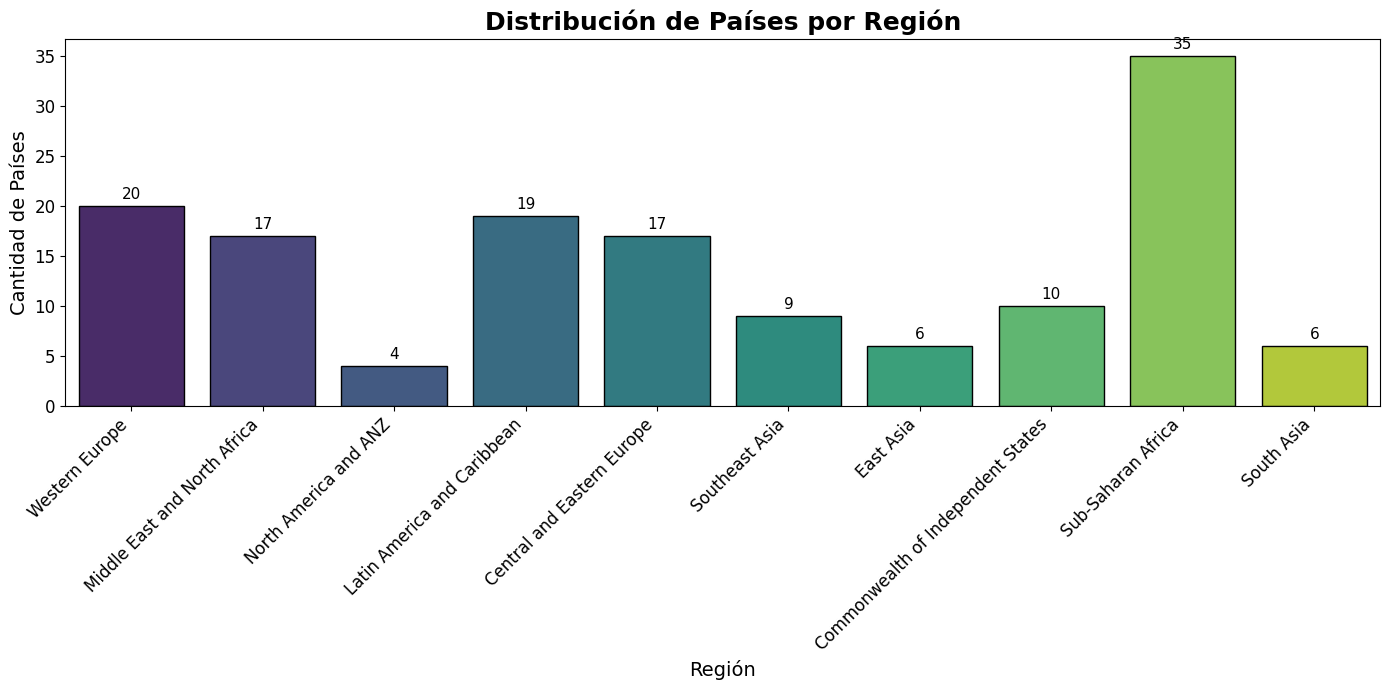

In [11]:
plt.figure(figsize=(14, 7))
ax = sns.countplot(
    data=df_1,
    x='Regional indicator',
    hue='Regional indicator',
    palette='viridis',
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Distribución de Países por Región', fontsize=18, fontweight='bold')
plt.xlabel('Región', fontsize=14)
plt.ylabel('Cantidad de Países', fontsize=14)
plt.legend().remove()  # Quitar leyenda

# Agregar etiquetas de conteo arriba de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=3)

plt.tight_layout()
plt.show()



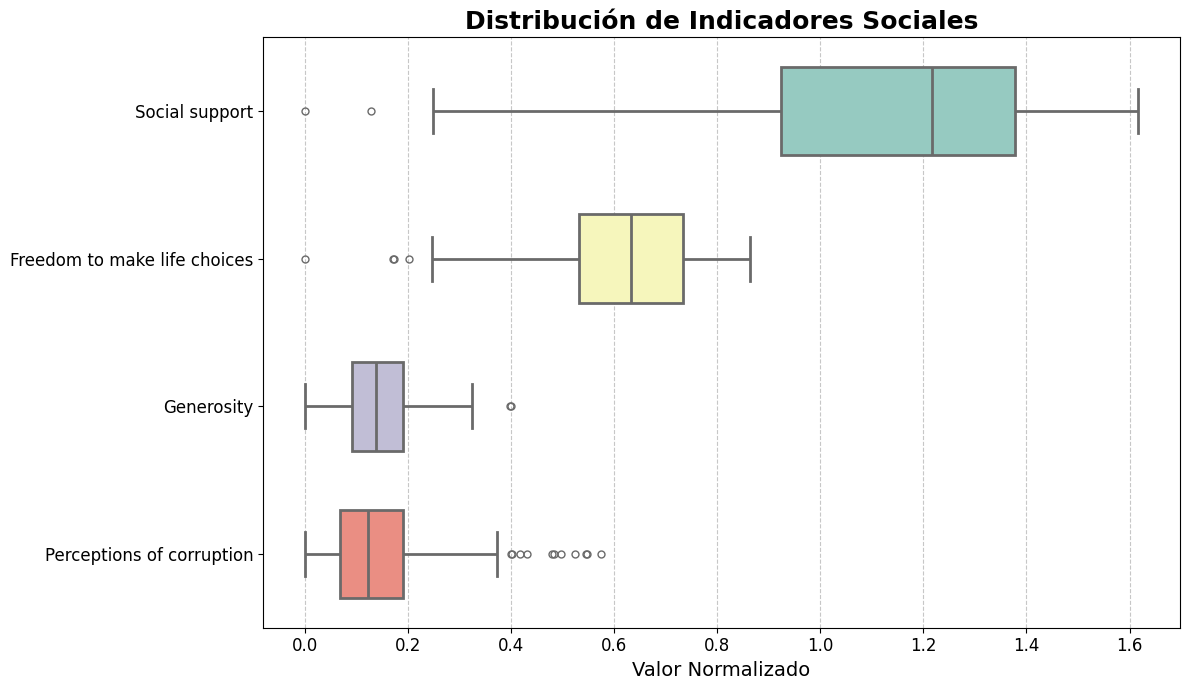

In [12]:
# Definir nuevamente la lista de características
list_features = ['Social support', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

# Volver a generar el gráfico mejorado
plt.figure(figsize=(12, 7))
ax = sns.boxplot(
    data=df_1.loc[:, list_features],
    orient='h',
    palette='Set3',
    linewidth=2,
    fliersize=5,  # tamaño de los outliers
    width=0.6     # ancho de las cajas
)

# Mejorar el estilo
plt.title('Distribución de Indicadores Sociales', fontsize=18, fontweight='bold')
plt.xlabel('Valor Normalizado', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Agregar líneas horizontales suaves

# Bordes más visibles para cada caja
for patch in ax.artists:
    patch.set_edgecolor('black')
    patch.set_linewidth(2)

plt.tight_layout()
plt.show()



/tmp/ipython-input-1515727665.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


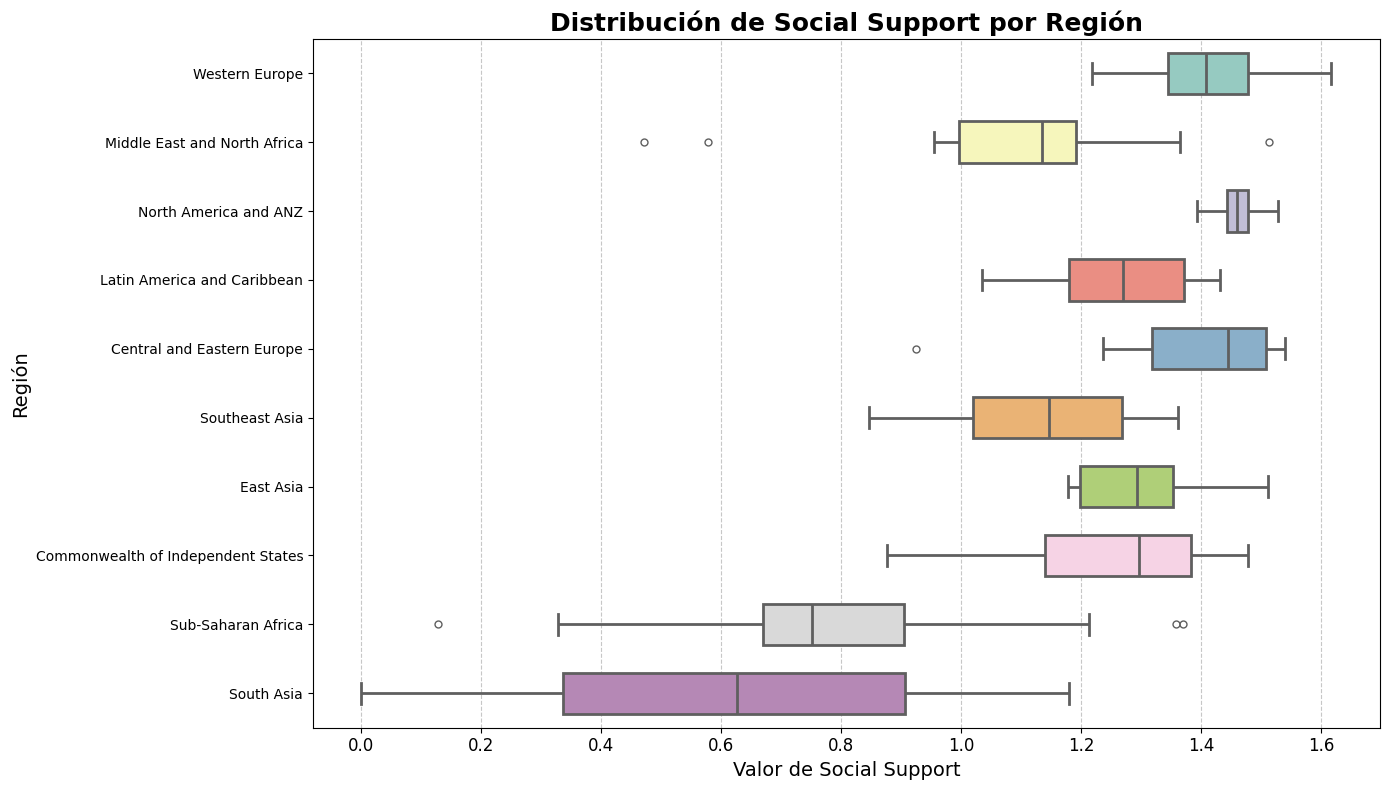

In [13]:
# Ahora realizaremos el boxplot pero agrupado por 'Regional indicator'

plt.figure(figsize=(14, 8))
ax = sns.boxplot(
    data=df_1,
    y='Regional indicator',
    x='Social support',
    palette='Set3',
    linewidth=2,
    fliersize=5,  # tamaño de los outliers
    width=0.6     # ancho de las cajas
)

# Mejorar el estilo
plt.title('Distribución de Social Support por Región', fontsize=18, fontweight='bold')
plt.xlabel('Valor de Social Support', fontsize=14)
plt.ylabel('Región', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Agregar líneas verticales suaves

# Bordes más visibles para cada caja
for patch in ax.artists:
    patch.set_edgecolor('black')
    patch.set_linewidth(2)

plt.tight_layout()
plt.show()



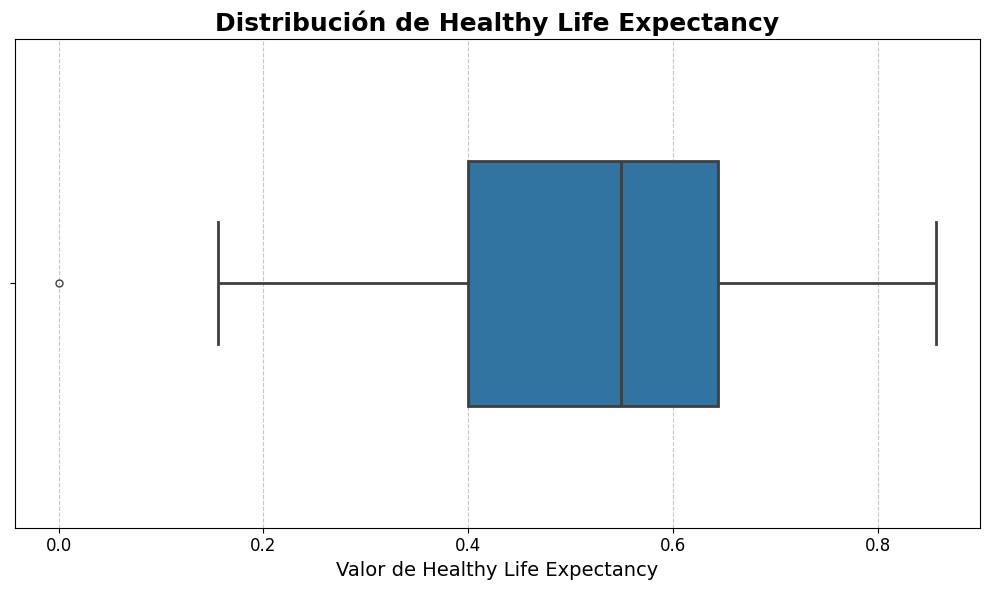

In [14]:
# Corrección completa del código que enviaste

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_1['Healthy life expectancy'],  # corregido
    orient='h',
    linewidth=2,
    fliersize=5,
    width=0.5
)

# Mejorar el estilo del gráfico
plt.title('Distribución de Healthy Life Expectancy', fontsize=18, fontweight='bold')
plt.xlabel('Valor de Healthy Life Expectancy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # líneas de referencia

plt.tight_layout()
plt.show()



/tmp/ipython-input-3259788583.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


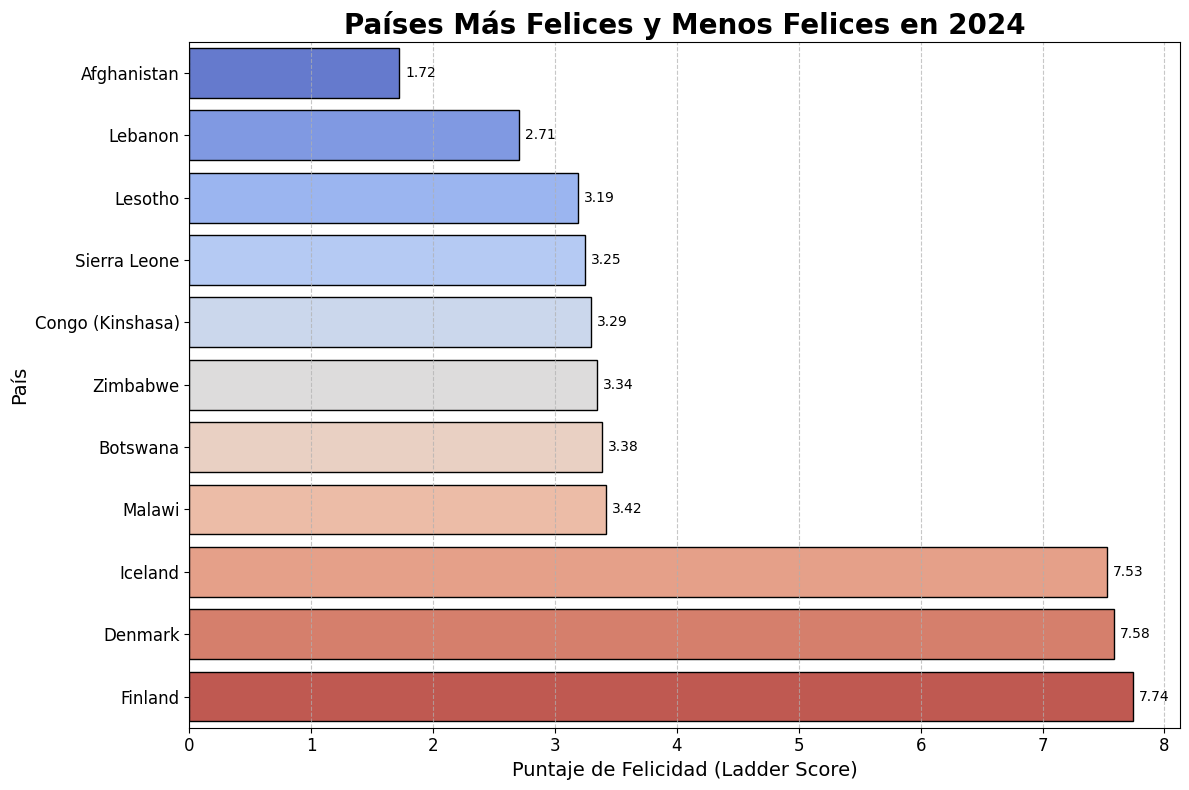

In [17]:
# Crear el subconjunto
df_1_happiest_unhappiest = df_1[(df_1['Ladder score'] > 7.4) | (df_1['Ladder score'] < 3.5)]

# Ordenar los países por Ladder score para una mejor presentación
df_1_happiest_unhappiest = df_1_happiest_unhappiest.sort_values('Ladder score', ascending=True)

# Crear el gráfico mejorado
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Ladder score',
    y='Country name',
    data=df_1_happiest_unhappiest,
    palette='coolwarm',
    edgecolor='black'
)

# Estética general
plt.title('Países Más Felices y Menos Felices en 2024', fontsize=20, fontweight='bold')
plt.xlabel('Puntaje de Felicidad (Ladder Score)', fontsize=14)
plt.ylabel('País', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Agregar etiquetas de valores al final de cada barra
for index, value in enumerate(df_1_happiest_unhappiest['Ladder score']):
    plt.text(value + 0.05, index, f'{value:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()



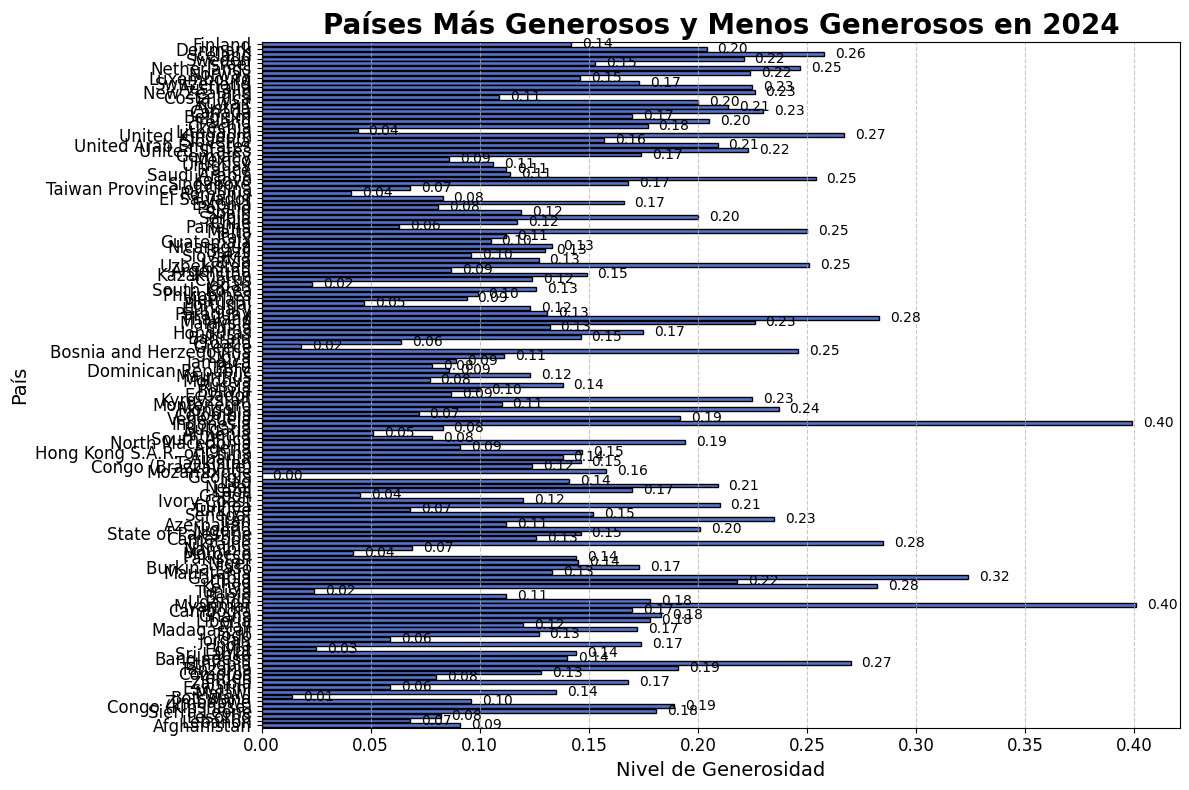

In [19]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Generosity',
    y='Country name',
    data=df_1,
    color='royalblue',  # Un color sólido agradable
    edgecolor='black'
)

# Mejorar la estética
plt.title('Países Más Generosos y Menos Generosos en 2024', fontsize=20, fontweight='bold')
plt.xlabel('Nivel de Generosidad', fontsize=14)
plt.ylabel('País', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Agregar etiquetas de valores al final de cada barra
for index, value in enumerate(df_1['Generosity']):
    plt.text(value + 0.005, index, f'{value:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()



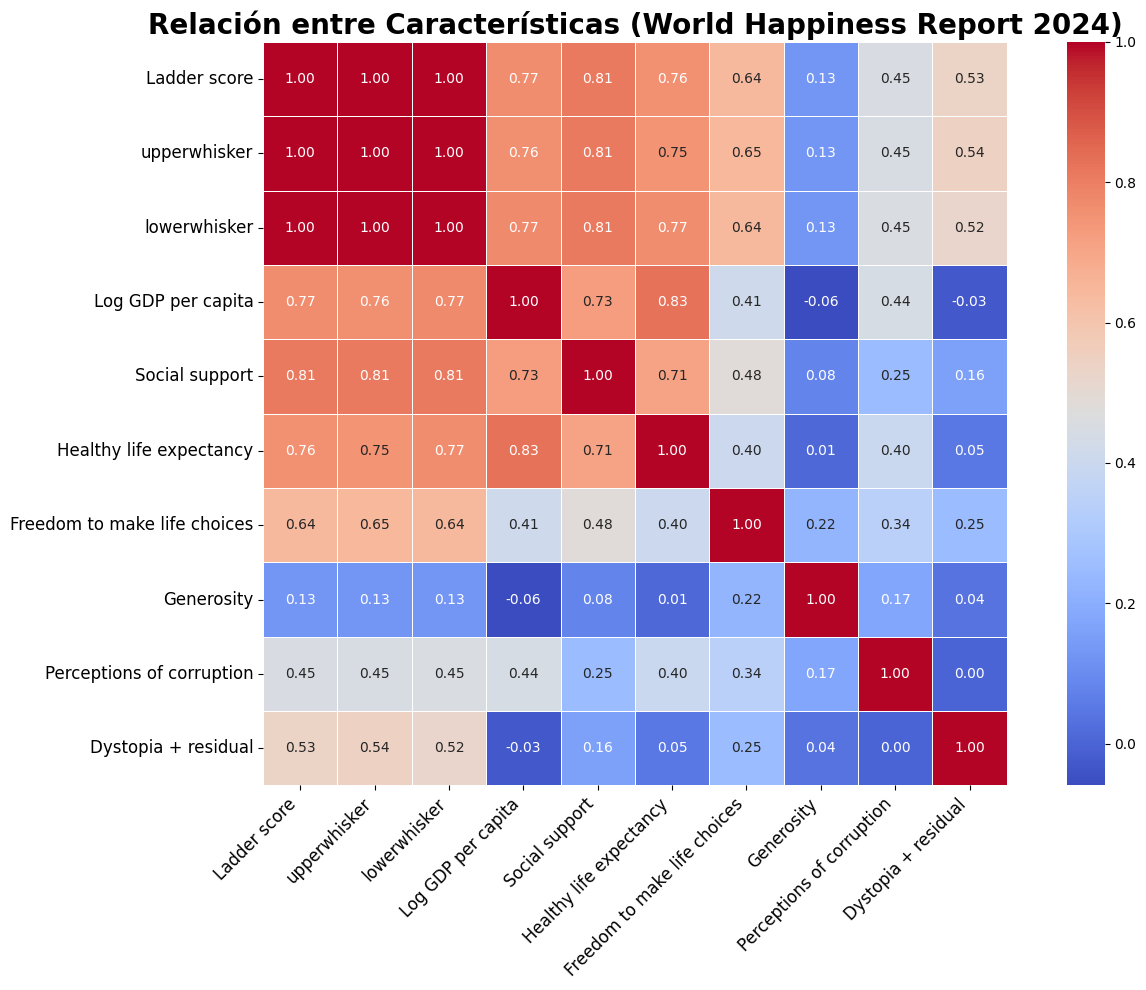

In [18]:
# Corrección completa y mejora del heatmap de correlaciones

# Definir correctamente las columnas no numéricas
non_numeric_columns = df_1.select_dtypes(exclude=['number']).columns

# Crear un dataframe solo con variables numéricas
df_numeric = df_1.drop(columns=non_numeric_columns)

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Crear el heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    linewidths=0.7,
    cmap='coolwarm',
    cbar=True,
    square=True,
    annot_kws={"size":10}
)

plt.title('Relación entre Características (World Happiness Report 2024)', fontsize=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()



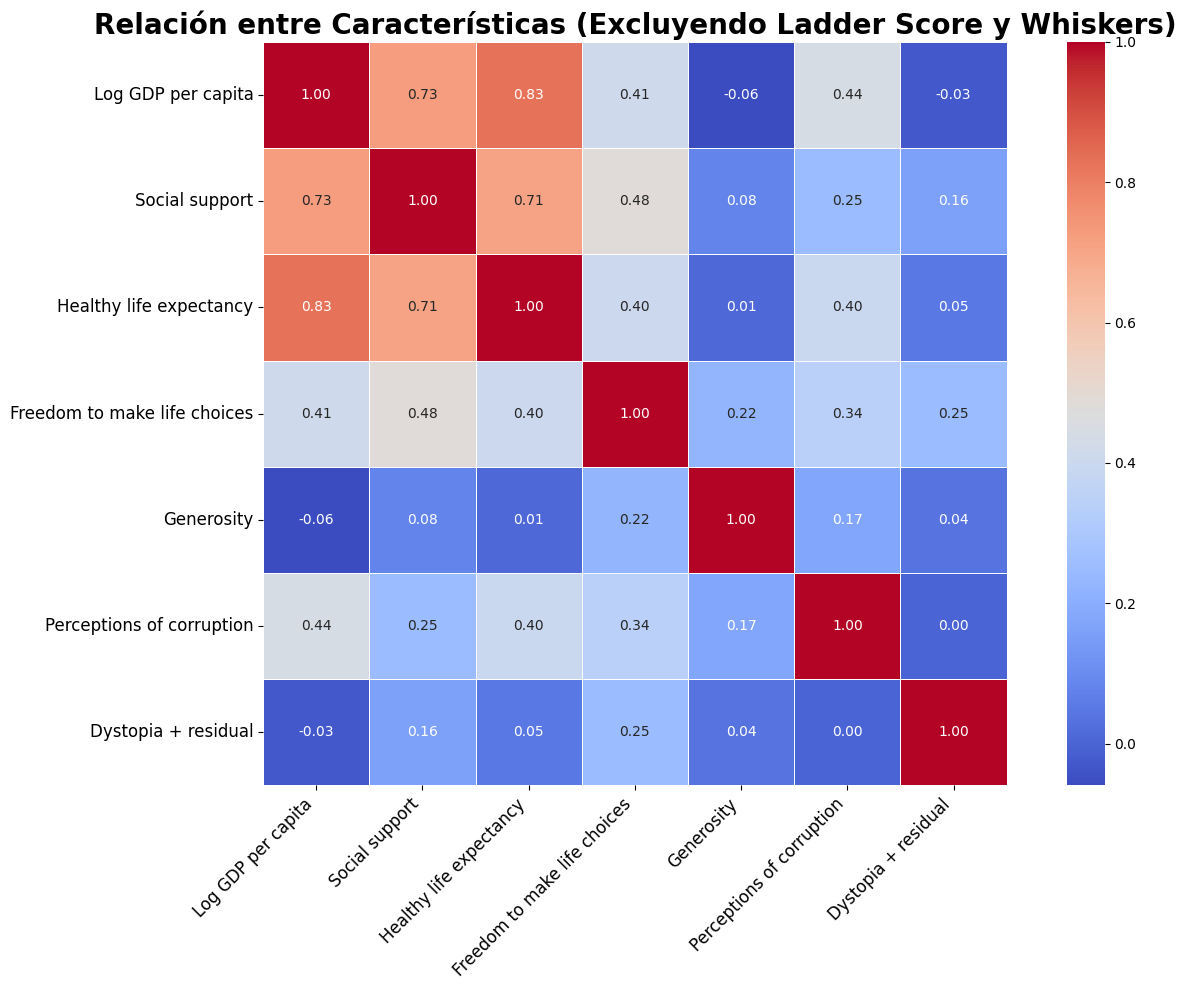

In [20]:
# Definir las columnas no numéricas
non_numeric_columns = df_1.select_dtypes(exclude=['number']).columns

# Lista de columnas adicionales a excluir
additional_exclude = ['Ladder score', 'upperwhisker', 'lowerwhisker']

# Crear un dataframe solo con variables numéricas y sin las columnas adicionales
df_numeric_filtered = df_1.drop(columns=list(non_numeric_columns) + additional_exclude)

# Calcular la nueva matriz de correlación
correlation_matrix_filtered = df_numeric_filtered.corr()

# Crear el nuevo heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix_filtered,
    annot=True,
    fmt='.2f',
    linewidths=0.7,
    cmap='coolwarm',
    cbar=True,
    square=True,
    annot_kws={"size":10}
)

plt.title('Relación entre Características (Excluyendo Ladder Score y Whiskers)', fontsize=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()



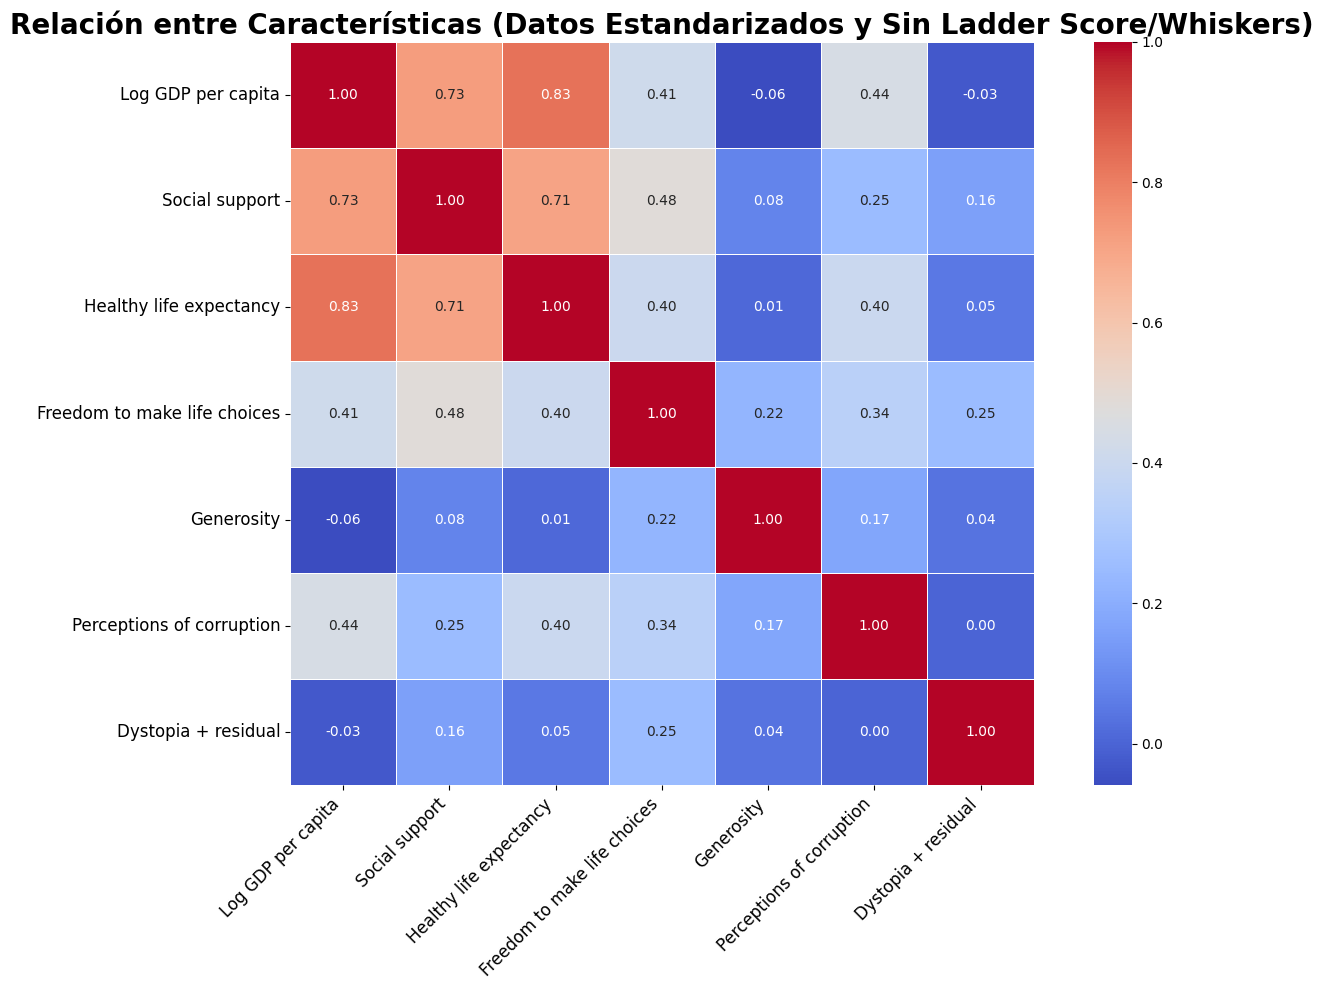

In [21]:
# Vamos a estandarizar los datos y volver a realizar el heatmap

from sklearn.preprocessing import StandardScaler

# Estandarizar los datos
scaler = StandardScaler()
df_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(df_numeric_filtered),
    columns=df_numeric_filtered.columns
)

# Calcular la matriz de correlación de los datos estandarizados
correlation_matrix_scaled = df_numeric_scaled.corr()

# Crear el heatmap de los datos estandarizados
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix_scaled,
    annot=True,
    fmt='.2f',
    linewidths=0.7,
    cmap='coolwarm',
    cbar=True,
    square=True,
    annot_kws={"size":10}
)

plt.title('Relación entre Características (Datos Estandarizados y Sin Ladder Score/Whiskers)', fontsize=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()



# **PCA**

In [22]:
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

features = ["Ladder score", "Log GDP per capita", "Social support", "Healthy life expectancy"]
fig = px.scatter_matrix(
    df_1,
    dimensions=features,
    color="Regional indicator"
)
fig.update_traces(diagonal_visible=False)
fig.show()

In [23]:
# Assuming df_1 contains the World Happiness Report data
X = df_1[["Ladder score", "Log GDP per capita", "Social support", "Healthy life expectancy"]]

pca = PCA(n_components=2)
components = pca.fit_transform(X)

fig = px.scatter(components, x=0, y=1, color=df_1['Regional indicator'],
                      text=df_1['Country name'])  # Add country name for text labels
fig.update_traces(textposition='top center')  # Adjust text position as needed
fig.show() #This line was also incorrectly indented

In [24]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Change df to df_1 to access 'Regional indicator'
fig = px.scatter(components, x=0, y=1, color=df_1['Regional indicator'])

for i, feature in enumerate(features):
    fig.add_annotation(
        ax=0, ay=0,
        axref="x", ayref="y",
        x=loadings[i, 0],
        y=loadings[i, 1],
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top"
    )
    fig.add_annotation(
        x=loadings[i, 0],
        y=loadings[i, 1],
        ax=0, ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5,
    )
fig.show()

In [25]:
# Add 'Country name' for text labels
fig = px.scatter(components, x=0, y=1, color=df_1['Regional indicator'],
                  text=df_1['Country name']) # add country name as text

for i, feature in enumerate(features):
    fig.add_annotation(
        ax=0, ay=0,
        axref="x", ayref="y",
        x=loadings[i, 0],
        y=loadings[i, 1],
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top"
    )
    fig.add_annotation(
        x=loadings[i, 0],
        y=loadings[i, 1],
        ax=0, ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5,
    )

fig.update_traces(textposition='top center') # adjust text position as needed
fig.show()

In [26]:
# Add 'Country name' for text labels
fig = px.scatter(components, x=0, y=1, color=df_1['Regional indicator'],
                  text=df_1['Country name']) # add country name as text

for i, feature in enumerate(features):
    fig.add_annotation(
        ax=0, ay=0,
        axref="x", ayref="y",
        x=loadings[i, 0],
        y=loadings[i, 1],
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top",
        arrowcolor="red"  # Set arrow color to red
    )
    fig.add_annotation(
        x=loadings[i, 0],
        y=loadings[i, 1],
        ax=0, ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5,
        font=dict(color="red")  # Set text color to red
    )

fig.update_traces(textposition='top center') # adjust text position as needed
fig.show()

In [27]:
df_pca = df_1[features].dropna()

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# Aplicar PCA
pca = PCA()
pca.fit(X_scaled)

# Obtener eigenvalores (varianzas explicadas)
eigenvalues = pca.explained_variance_

# Obtener eigenvectores (direcciones principales)
eigenvectors = pca.components_

# Crear DataFrame para eigenvalores
eigenvalues_df = pd.DataFrame({
    'Componente Principal': [f'CP{i+1}' for i in range(len(eigenvalues))],
    'Valor Propio (Eigenvalue)': eigenvalues
})

# Crear DataFrame para eigenvectores (loadings)
eigenvectors_df = pd.DataFrame(
    eigenvectors.T,
    columns=[f'CP{i+1}' for i in range(eigenvectors.shape[0])],
    index=["Índice de felicidad", "PIB per cápita (log)", "Apoyo social", "Esperanza de vida saludable"]
)
print(eigenvalues_df)
print(eigenvectors_df)

  Componente Principal  Valor Propio (Eigenvalue)
0                  CP1                   3.324498
1                  CP2                   0.351184
2                  CP3                   0.183239
3                  CP4                   0.169248
                                  CP1       CP2       CP3       CP4
Índice de felicidad          0.505773  0.351262  0.766122  0.184027
PIB per cápita (log)         0.503824 -0.442766 -0.293251  0.681267
Apoyo social                 0.490998  0.631852 -0.566671 -0.196385
Esperanza de vida saludable  0.499275 -0.530412  0.077106 -0.680766


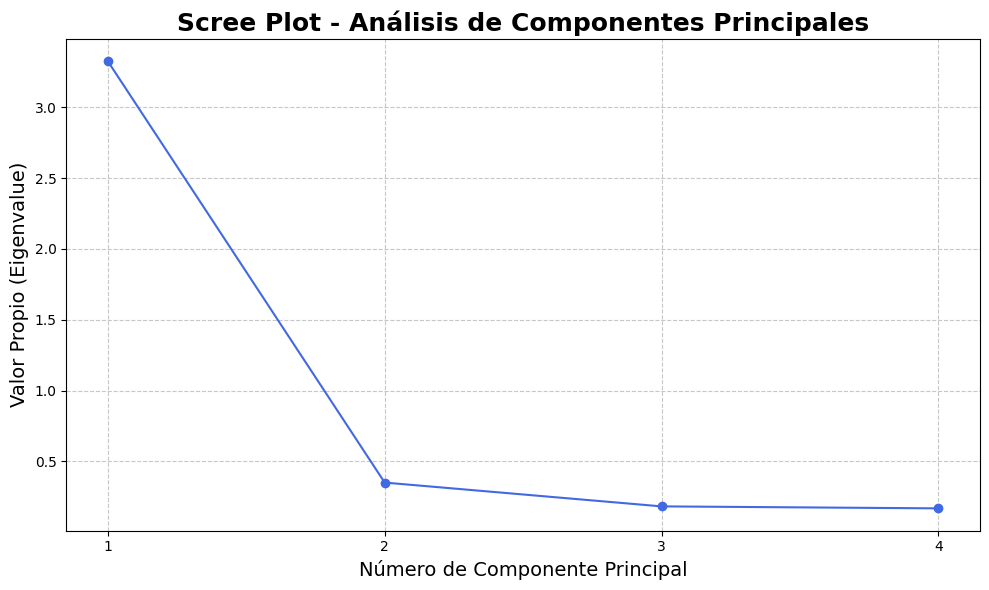

In [28]:
# Crear un Scree Plot (gráfico de eigenvalues) profesional

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o', linestyle='-', color='royalblue')
plt.title('Scree Plot - Análisis de Componentes Principales', fontsize=18, fontweight='bold')
plt.xlabel('Número de Componente Principal', fontsize=14)
plt.ylabel('Valor Propio (Eigenvalue)', fontsize=14)
plt.xticks(range(1, len(eigenvalues)+1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


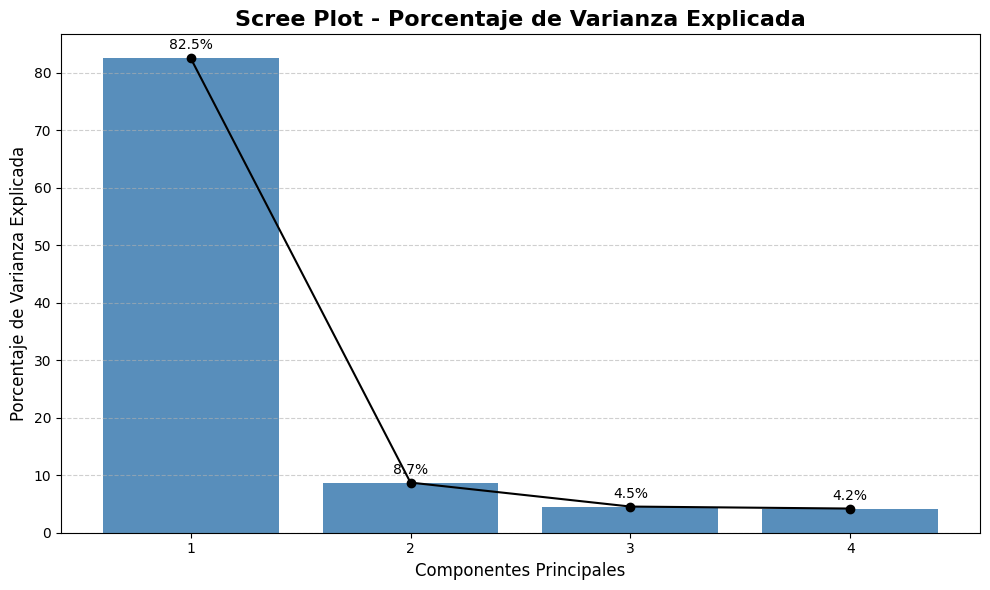

In [29]:
# Crear un Scree Plot tipo barra + línea + anotaciones de porcentaje como en la imagen de ejemplo

# Calcular porcentaje de varianza explicada
explained_variance_ratio = pca.explained_variance_ratio_ * 100

# Gráfico combinado (barras + línea) con etiquetas de porcentaje
plt.figure(figsize=(10, 6))
bars = plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, color='steelblue', alpha=0.9)
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, color='black', marker='o')

# Etiquetas de porcentaje encima de cada barra
for i, var in enumerate(explained_variance_ratio):
    plt.text(i+1, var + 1, f"{var:.1f}%", ha='center', va='bottom', fontsize=10)

# Títulos y ejes
plt.title("Scree Plot - Porcentaje de Varianza Explicada", fontsize=16, fontweight='bold')
plt.xlabel("Componentes Principales", fontsize=12)
plt.ylabel("Porcentaje de Varianza Explicada", fontsize=12)
plt.xticks(range(1, len(explained_variance_ratio)+1))
plt.yticks(range(0, 90, 10))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



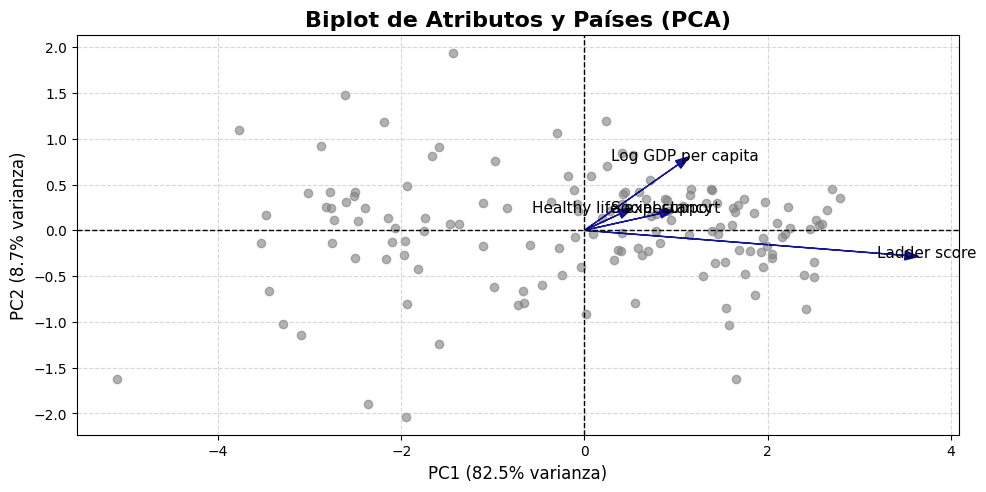

In [32]:
# Crear figura del Biplot
plt.figure(figsize=(10, 8))

# Transform the data to the first 2 principal components
X_pca = pca.transform(X_scaled)[:, :2]

# 1. Graficar los puntos (países)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='grey', label="Países")

# 2. Graficar vectores (atributos)
for i, var in enumerate(features):
    plt.arrow(0, 0,
              loadings[i, 0]*3,  # Escalado para visibilidad
              loadings[i, 1]*3,
              color='darkblue', alpha=0.9, head_width=0.1)
    plt.text(loadings[i, 0]*3.2,
             loadings[i, 1]*3.2,
             var, color='black', fontsize=11, ha='center')

# Líneas guía y formato
plt.axhline(0, color='black', lw=1, linestyle='--')
plt.axvline(0, color='black', lw=1, linestyle='--')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('Biplot de Atributos y Países (PCA)', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3729969962.py:11: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



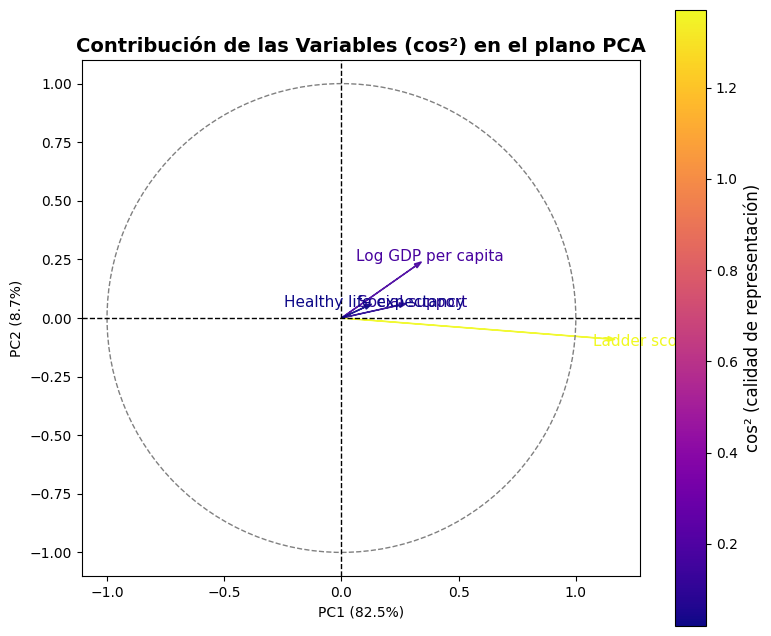

In [33]:
# Las coordenadas de las variables en el plano PC1-PC2 son los loadings
loadings_2d = loadings[:, :2]
cos2 = np.sum(loadings_2d**2, axis=1)

# Normalizar cos2 para colorear
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=min(cos2), vmax=max(cos2))
cmap = cm.get_cmap("plasma")
colors = [cmap(norm(value)) for value in cos2]

# Gráfico tipo fviz_pca_var con color según cos2
fig, ax = plt.subplots(figsize=(8, 8)) # Create fig and ax objects
for i, var in enumerate(features):
    ax.arrow(0, 0, # Use ax.arrow instead of plt.arrow
              loadings[i, 0],
              loadings[i, 1],
              color=colors[i], alpha=0.9,
              head_width=0.02, length_includes_head=True)
    ax.text(loadings[i, 0]*1.1, # Use ax.text instead of plt.text
             loadings[i, 1]*1.1,
             var, fontsize=11, ha='center', va='center', color=colors[i])

# Agregar círculo guía
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(circle) # Use ax.add_patch

# Ajustes visuales
ax.axhline(0, color='black', linestyle='--', lw=1) # Use ax.axhline
ax.axvline(0, color='black', linestyle='--', lw=1) # Use ax.axvline
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)') # Use ax.set_xlabel
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)') # Use ax.set_ylabel
ax.set_title('Contribución de las Variables (cos²) en el plano PCA', fontsize=14, fontweight='bold') # Use ax.set_title
ax.grid(False)
ax.set_aspect('equal', adjustable='box') # Use ax.set_aspect

# Agregar barra de color (leyenda cos2)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.8) # Specify ax in colorbar function
cbar.set_label('cos² (calidad de representación)', fontsize=12)

plt.tight_layout()
plt.show()

In [34]:
from sklearn.cluster import KMeans
import plotly.graph_objects as go

#Calcular inercia para diferentes k
inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

# Graficar con Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(K_range),
    y=inertias,
    mode='lines+markers',
    line=dict(color='royalblue'),
    marker=dict(size=8)
))

fig.update_layout(
    title="Método del Codo - Selección del Número Óptimo de Clusters",
    xaxis_title="Número de Clusters (k)",
    yaxis_title="Inercia (Suma de distancias internas)",
    template="plotly_white"
)

fig.show()


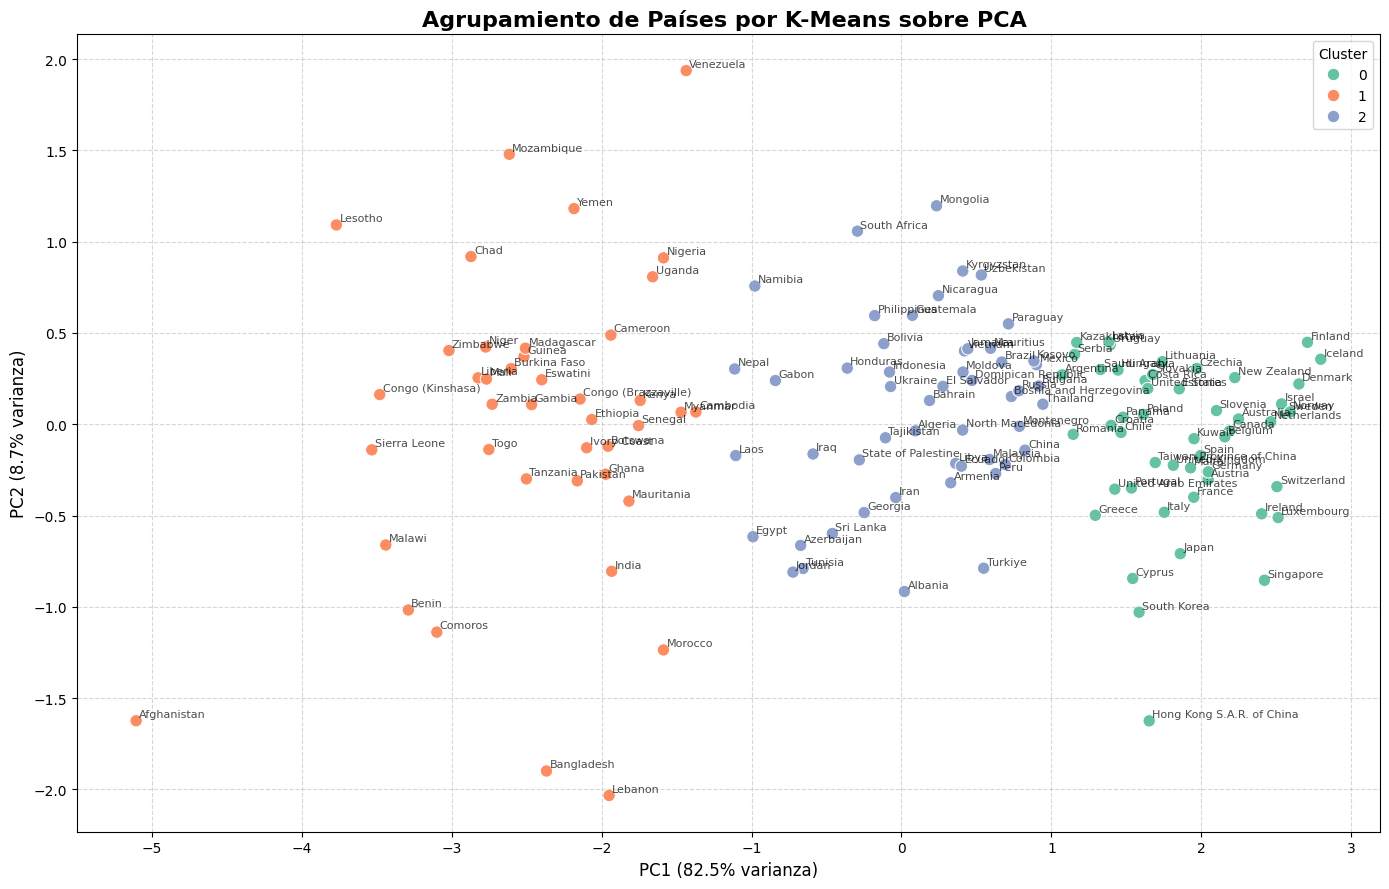

In [35]:
# Aplicar KMeans con un número razonable de clusters (por ejemplo, 3)

# Definir el número deseado de clusters (por ejemplo, 4)
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Transform the data to the first 2 principal components
X_pca = pca.transform(X_scaled)[:, :2]

# Crear DataFrame para graficar using the transformed data
pca_cluster_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_cluster_df["Cluster"] = clusters
pca_cluster_df["País"] = df.loc[df_pca.index, "Country name"].values

# Agregar nombres de los países a cada punto en el gráfico de clusters sobre PCA

plt.figure(figsize=(14, 9))
sns.scatterplot(data=pca_cluster_df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=80)

# Añadir etiquetas de país
for i in range(pca_cluster_df.shape[0]):
    plt.text(
        pca_cluster_df["PC1"][i] + 0.02,
        pca_cluster_df["PC2"][i] + 0.02,
        pca_cluster_df["País"][i],
        fontsize=8,
        alpha=0.7
    )

plt.title("Agrupamiento de Países por K-Means sobre PCA ", fontsize=16, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

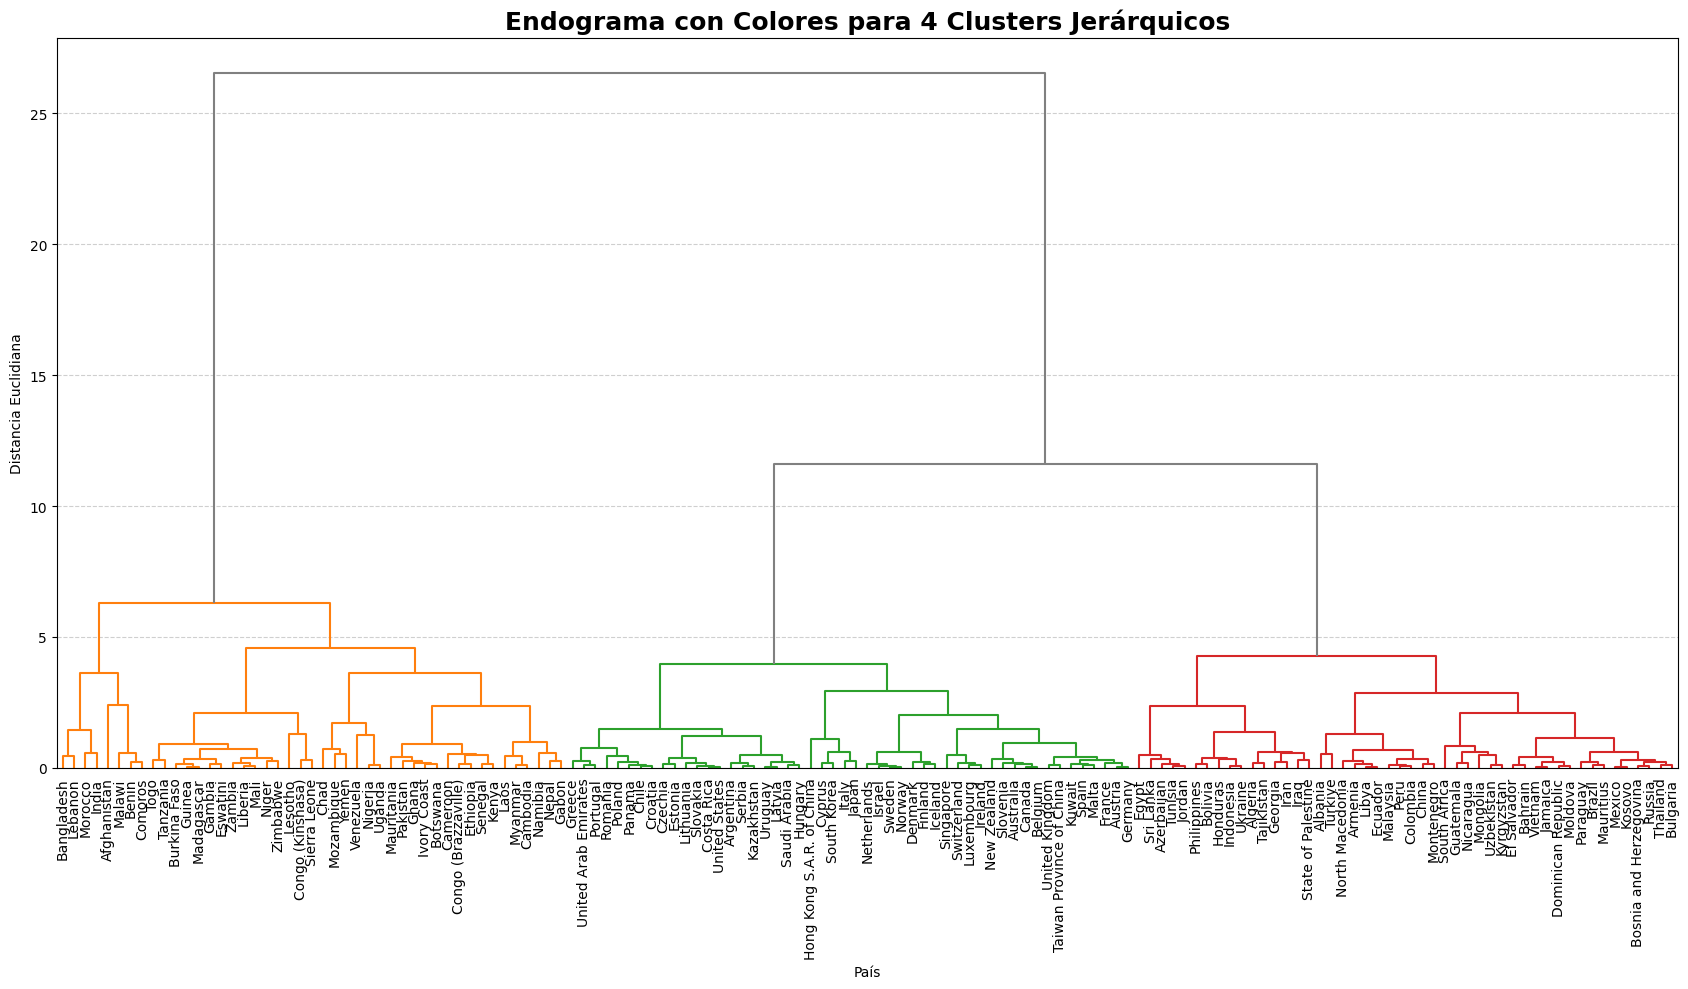

In [39]:
# Crear un dendrograma con nombres de países rotados 90 grados y selección de clusters (corte)

from scipy.cluster.hierarchy import fcluster, linkage, dendrogram

# Generar etiquetas de países desde el DataFrame original alineado con PCA
labels = df.loc[df_pca.index, "Country name"].values

# Crear linkage nuevamente para asegurar consistencia
linked = linkage(X_pca, method='ward')

# Generar los clusters
cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')

# Crear un dendrograma con colores que representen visualmente los 4 clusters seleccionados

plt.figure(figsize=(17, 10))
dendrogram(
    linked,
    labels=labels,
    orientation='top',
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=linked[-(n_clusters-1), 2],  # Corta en la altura que genera n_clusters
    above_threshold_color='gray'  # Color para ramas superiores al corte
)

plt.title('Endograma con Colores para 4 Clusters Jerárquicos', fontsize=18, fontweight='bold')
plt.xlabel('País')
plt.ylabel('Distancia Euclidiana')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [40]:
# Crear una nueva columna en la base original con el número de cluster jerárquico asignado a cada país

# Asignar los clusters jerárquicos a los datos originales usando las posiciones alineadas con PCA
df_clusterizado = df.copy()
df_clusterizado['Cluster_HC'] = np.nan

# Asignar etiquetas de cluster a los países que fueron usados en el PCA
cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')
df_clusterizado.loc[df_pca.index, 'Cluster_HC'] = cluster_labels

# Convertir a entero para visualización
df_clusterizado['Cluster_HC'] = df_clusterizado['Cluster_HC'].astype('Int64')
print(df_clusterizado.head())


  Country name            Regional indicator  Ladder score  upperwhisker  \
0      Finland                Western Europe         7.741         7.815   
1      Denmark                Western Europe         7.583         7.665   
2      Iceland                Western Europe         7.525         7.618   
3       Sweden                Western Europe         7.344         7.422   
4       Israel  Middle East and North Africa         7.341         7.405   

   lowerwhisker  Log GDP per capita  Social support  Healthy life expectancy  \
0         7.667               1.844           1.572                    0.695   
1         7.500               1.908           1.520                    0.699   
2         7.433               1.881           1.617                    0.718   
3         7.267               1.878           1.501                    0.724   
4         7.277               1.803           1.513                    0.740   

   Freedom to make life choices  Generosity  Perceptions of co

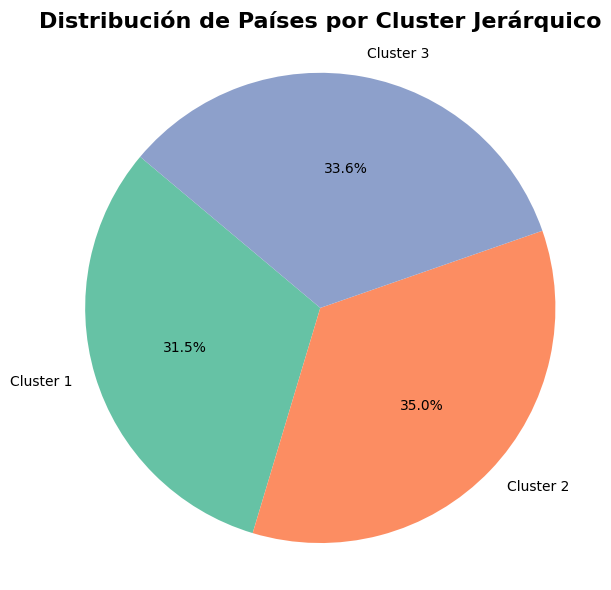

In [41]:
# Crear un gráfico circular que muestre la distribución de países por cluster jerárquico

# Contar países por cluster (ignorando NaN)
cluster_counts = df_clusterizado['Cluster_HC'].value_counts().sort_index()

# Crear gráfico circular
plt.figure(figsize=(6, 6))
plt.pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index],
        autopct='%1.1f%%', startangle=140, colors=plt.cm.Set2.colors)
plt.title('Distribución de Países por Cluster Jerárquico', fontsize=16, fontweight='bold')
plt.axis('equal')  # Asegura que el círculo no esté deformado
plt.tight_layout()
plt.show()


/tmp/ipython-input-668788743.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




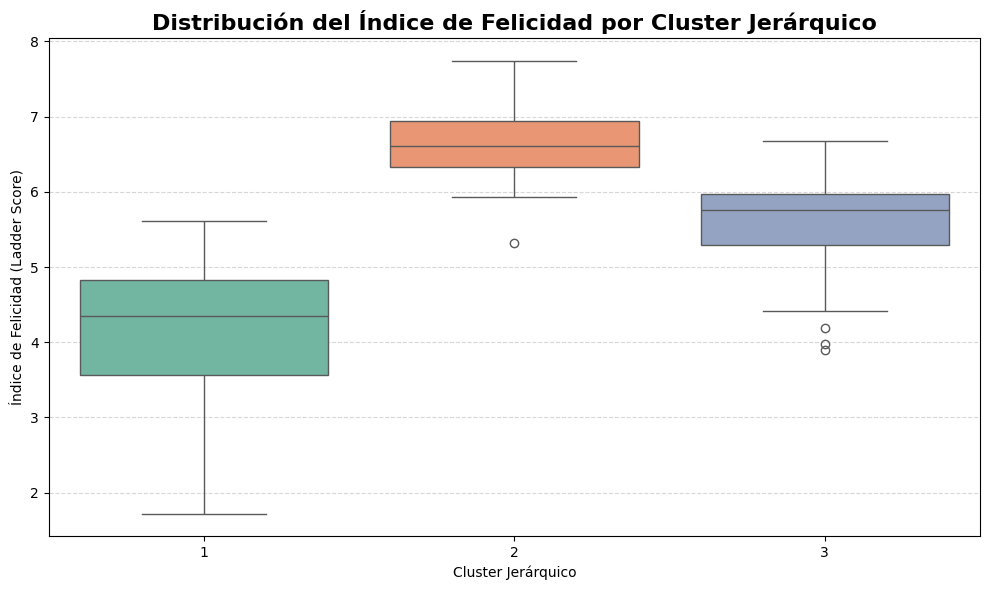

In [42]:
# Crear un boxplot que muestre la relación entre los clusters jerárquicos y el índice de felicidad

# Asegurar que los datos están completos
df_box = df_clusterizado.dropna(subset=['Cluster_HC', 'Ladder score'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_box, x='Cluster_HC', y='Ladder score', palette='Set2')
plt.title('Distribución del Índice de Felicidad por Cluster Jerárquico', fontsize=16, fontweight='bold')
plt.xlabel('Cluster Jerárquico')
plt.ylabel('Índice de Felicidad (Ladder Score)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1006818816.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




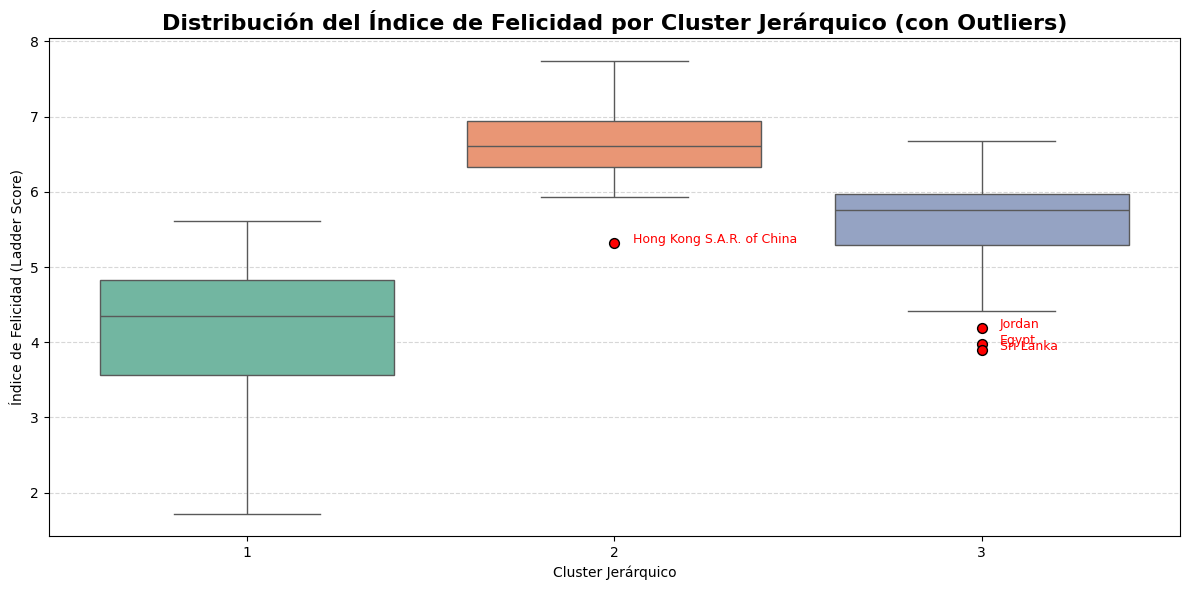

In [43]:
# Volver a crear el boxplot de clusters con índice de felicidad y resaltar los países atípicos

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_box, x='Cluster_HC', y='Ladder score', palette='Set2')

# Calcular los outliers para cada cluster
def get_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return group[(group < lower_bound) | (group > upper_bound)]

outliers = df_box.groupby('Cluster_HC')['Ladder score'].apply(get_outliers).droplevel(0)
outliers_df = df_box[df_box.index.isin(outliers.index)]

# Resaltar los países atípicos
for i in outliers_df.index:
    x = df_box.loc[i, 'Cluster_HC'] - 1  # eje x: cluster (indexado desde 0)
    y = df_box.loc[i, 'Ladder score']
    label = df_box.loc[i, 'Country name']
    plt.scatter(x, y, color='red', s=50, edgecolor='black', zorder=5)
    plt.text(x + 0.05, y, label, fontsize=9, color='red', ha='left')

plt.title('Distribución del Índice de Felicidad por Cluster Jerárquico (con Outliers)', fontsize=16, fontweight='bold')
plt.xlabel('Cluster Jerárquico')
plt.ylabel('Índice de Felicidad (Ladder Score)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [44]:
# Filtrar el DataFrame original para obtener solo los países que pertenecen al Cluster 1
df_cluster_1 = df_clusterizado[df_clusterizado['Cluster_HC'] == 1]
print(df_cluster_1.head())


           Country name           Regional indicator  Ladder score  \
78            Venezuela  Latin America and Caribbean         5.607   
88  Congo (Brazzaville)           Sub-Saharan Africa         5.221   
89           Mozambique           Sub-Saharan Africa         5.216   
92                Nepal                   South Asia         5.158   
93                 Laos               Southeast Asia         5.139   

    upperwhisker  lowerwhisker  Log GDP per capita  Social support  \
78         5.725         5.489               0.000           1.321   
88         5.396         5.047               0.892           0.622   
89         5.406         5.027               0.560           0.883   
92         5.290         5.027               0.965           0.990   
93         5.261         5.017               1.208           0.846   

    Healthy life expectancy  Freedom to make life choices  Generosity  \
78                    0.491                         0.518       0.192   
88          

In [45]:
# Filtrar el DataFrame original para obtener solo los países que pertenecen al Cluster 1
df_cluster_2 = df_clusterizado[df_clusterizado['Cluster_HC'] == 2]
print(df_cluster_2.head())

  Country name            Regional indicator  Ladder score  upperwhisker  \
0      Finland                Western Europe         7.741         7.815   
1      Denmark                Western Europe         7.583         7.665   
2      Iceland                Western Europe         7.525         7.618   
3       Sweden                Western Europe         7.344         7.422   
4       Israel  Middle East and North Africa         7.341         7.405   

   lowerwhisker  Log GDP per capita  Social support  Healthy life expectancy  \
0         7.667               1.844           1.572                    0.695   
1         7.500               1.908           1.520                    0.699   
2         7.433               1.881           1.617                    0.718   
3         7.267               1.878           1.501                    0.724   
4         7.277               1.803           1.513                    0.740   

   Freedom to make life choices  Generosity  Perceptions of co

In [46]:
# Filtrar el DataFrame original para obtener solo los países que pertenecen al Cluster 1
df_cluster_3 = df_clusterizado[df_clusterizado['Cluster_HC'] == 3]
print(df_cluster_3.head())

   Country name           Regional indicator  Ladder score  upperwhisker  \
24       Mexico  Latin America and Caribbean         6.678         6.781   
28       Kosovo   Central and Eastern Europe         6.561         6.667   
32  El Salvador  Latin America and Caribbean         6.469         6.599   
41    Guatemala  Latin America and Caribbean         6.287         6.457   
42    Nicaragua  Latin America and Caribbean         6.284         6.433   

    lowerwhisker  Log GDP per capita  Social support  Healthy life expectancy  \
24         6.575               1.521           1.241                    0.544   
28         6.455               1.364           1.277                    0.599   
32         6.338               1.265           1.080                    0.549   
41         6.117               1.260           1.169                    0.467   
42         6.135               1.097           1.263                    0.542   

    Freedom to make life choices  Generosity  Perception